# 06 — Random Forest

## Theory

A single Decision Tree is a high-variance model — small changes in the
training data can produce a very different tree. Random Forest tames that
variance by training **many** trees and averaging their votes, using two
sources of randomness to make the trees diverse enough that their errors
partially cancel out:

1. **Bagging (Bootstrap Aggregating):** each tree is trained on a random
   sample of the training data, drawn *with replacement* (a "bootstrap
   sample," the same size as the original training set but with ~63% unique
   rows). Averaging predictions from models trained on different resamples
   of the data reduces variance without increasing bias — this is the
   statistical justification for bagging in general.
2. **Feature randomness:** at each split, instead of considering all
   features, each tree only considers a random subset of size
   `max_features`. This decorrelates the trees — without it, all trees would
   tend to split on the same few strongest features and end up highly
   correlated, which would limit how much averaging can reduce variance.

**Out-of-bag (OOB) estimate:** since each tree only sees ~63% of the
training rows, the other ~37% ("out-of-bag" for that tree) can be used to
estimate generalization error almost for free, without a separate
validation split — each row gets predicted by the subset of trees that
didn't see it during training.

**Feature importance:** Random Forest also gives a natural measure of how
much each feature contributes, typically the mean decrease in impurity
(Gini) that feature's splits produce, averaged across all trees.

A key mental model: **adding more trees (`n_estimators`) essentially never
overfits** — more averaging can only reduce variance further (at a compute
cost, with diminishing returns). What *can* still overfit is each
**individual tree's** complexity — hence Random Forest still exposes
`max_depth`/`min_samples_leaf`, same as a standalone Decision Tree.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [2]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


OOB score (generalization estimate from training data alone): 0.734
--- Random Forest (baseline) ---
              precision    recall  f1-score   support

   good risk       0.77      0.91      0.84       140
    bad risk       0.64      0.38      0.48        60

    accuracy                           0.75       200
   macro avg       0.71      0.65      0.66       200
weighted avg       0.73      0.75      0.73       200

ROC-AUC: 0.754


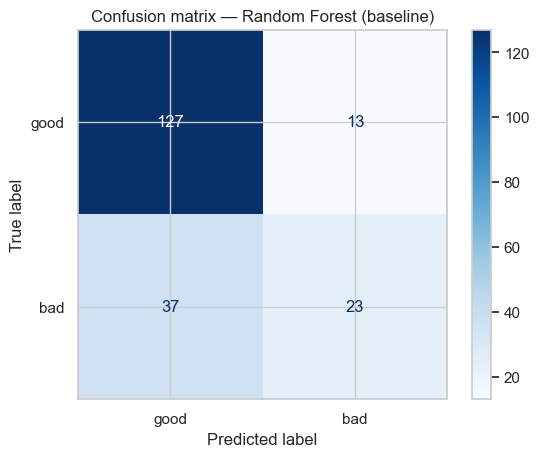

In [3]:
from sklearn.ensemble import RandomForestClassifier

baseline = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)
baseline.fit(X_train, y_train)

print(f"OOB score (generalization estimate from training data alone): {baseline.oob_score_:.3f}")
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]
evaluate(baseline, X_test, y_test, y_pred, y_proba, label="Random Forest (baseline)")


## Regularization — per-tree complexity, not tree *count*

As noted above, `n_estimators` mainly costs compute time, not
generalization, once it's "enough" (we can check this directly below). The
regularization knobs that actually matter are the same ones a single tree
exposes, now applied per-tree inside the forest: `max_depth`,
`min_samples_leaf`, and `max_features` (which additionally controls
tree-to-tree correlation, not just individual tree complexity).


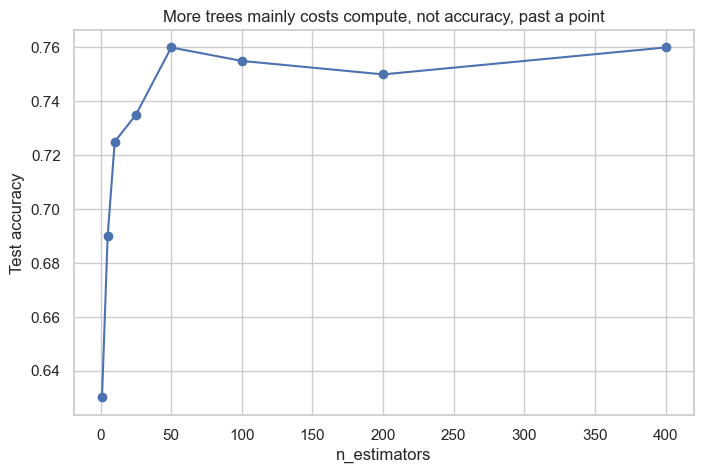

In [4]:
from sklearn.metrics import accuracy_score

n_estimators_range = [1, 5, 10, 25, 50, 100, 200, 400]
test_acc = []
for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    test_acc.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, test_acc, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Test accuracy")
plt.title("More trees mainly costs compute, not accuracy, past a point")
plt.show()


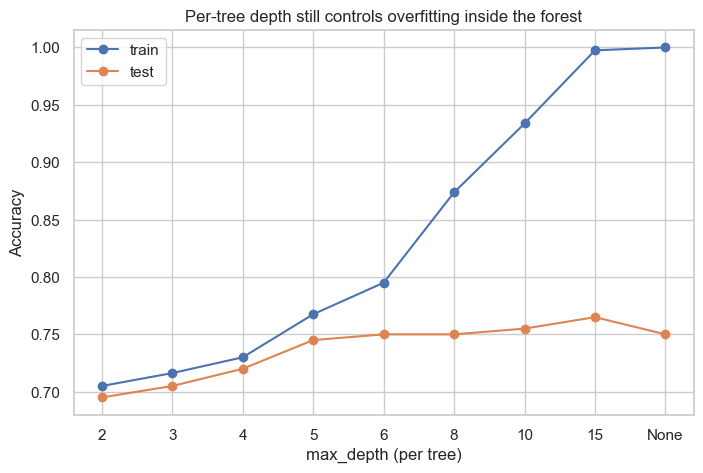

In [5]:
depths = [2, 3, 4, 5, 6, 8, 10, 15, None]
train_acc, test_acc = [], []
for d in depths:
    rf = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, rf.predict(X_test)))

x_labels = [str(d) for d in depths]
plt.figure(figsize=(8, 5))
plt.plot(x_labels, train_acc, marker="o", label="train")
plt.plot(x_labels, test_acc, marker="o", label="test")
plt.xlabel("max_depth (per tree)")
plt.ylabel("Accuracy")
plt.title("Per-tree depth still controls overfitting inside the forest")
plt.legend()
plt.show()


## Hyperparameter tuning

The joint space of `n_estimators` x `max_depth` x `min_samples_leaf` x
`max_features` gets large quickly, so an exhaustive grid search would be
wasteful — we use `RandomizedSearchCV` instead, which samples a fixed
number of random combinations from the space and is usually nearly as good
as a full grid search for a fraction of the compute (see the general
cross-validation theory in earlier notebooks — the same logic applies here,
just with random sampling instead of an exhaustive grid).


Best params: {'n_estimators': 300, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': None}
Best CV ROC-AUC: 0.755
--- Random Forest (tuned) ---
              precision    recall  f1-score   support

   good risk       0.77      0.96      0.85       140
    bad risk       0.77      0.33      0.47        60

    accuracy                           0.77       200
   macro avg       0.77      0.65      0.66       200
weighted avg       0.77      0.77      0.74       200

ROC-AUC: 0.781


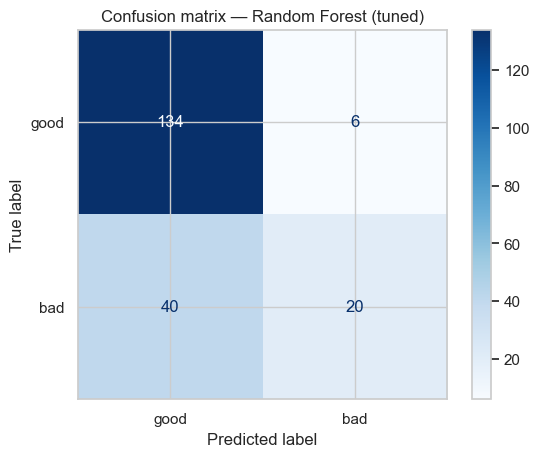

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_leaf": [1, 2, 4, 8, 16],
    "max_features": ["sqrt", "log2", 0.5, None],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist, n_iter=30, scoring="roc_auc",
    cv=5, random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV ROC-AUC: {search.best_score_:.3f}")

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]
evaluate(best_rf, X_test, y_test, y_pred, y_proba, label="Random Forest (tuned)")


## Feature importance

A nice side benefit of tree ensembles: which features actually drove the
predictions.


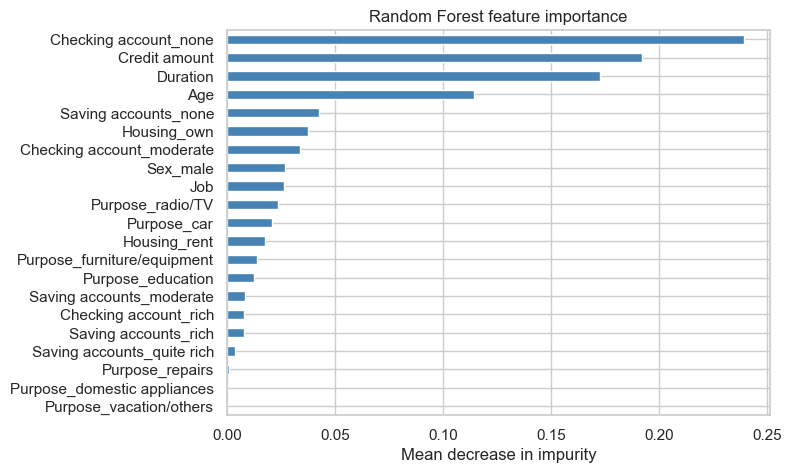

In [7]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Random Forest feature importance")
plt.xlabel("Mean decrease in impurity")
plt.show()


## Decision threshold tuning

Every classifier we use here can produce a **predicted probability** `P(bad | x)`
in addition to a hard label. Scikit-learn's `.predict()` turns that probability
into a 0/1 label by applying a fixed **threshold of 0.5**: if `P(bad) >= 0.5`
predict "bad risk", otherwise predict "good risk".

0.5 is just a default — it is not guaranteed to be the best cutoff for your
problem, and on this dataset it is almost certainly the wrong one. Two
reasons the optimal threshold can differ from 0.5:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so a model
   has to be unusually confident before `P(bad)` clears 0.5 — the default
   cutoff quietly favours the majority "good" class and suppresses recall on
   the class we actually care about. (Reweighting the loss with
   `class_weight="balanced"` is the other standard lever for this; it shifts
   roughly the same boundary, but requires retraining.)
2. **Asymmetric costs.** A false negative and a false positive rarely cost the
   same in the real world — approving a loan that defaults costs the lender
   the outstanding principal, while declining an applicant who would have
   repaid costs only the foregone interest. Moving the threshold trades
   precision for recall (or vice versa) along the model's ROC /
   precision-recall curve — it does not require retraining the model at all.

Two curves help pick a threshold:

- **ROC curve** — plots True Positive Rate vs. False Positive Rate as the
  threshold sweeps from 1 to 0. **Youden's J statistic** `J = TPR - FPR` is
  maximized at the threshold that best separates the classes when both error
  types are weighted equally.
- **Precision-Recall curve** — plots precision vs. recall as the threshold
  sweeps. More informative than ROC when classes are imbalanced. The
  threshold that maximizes the **F1 score** (harmonic mean of precision and
  recall) is a common choice when you care about both error types but the
  positive class is what matters.

Below we compute both curves, find the Youden's-J-optimal and
F1-optimal thresholds, and compare the resulting metrics against the
default 0.5 cutoff.


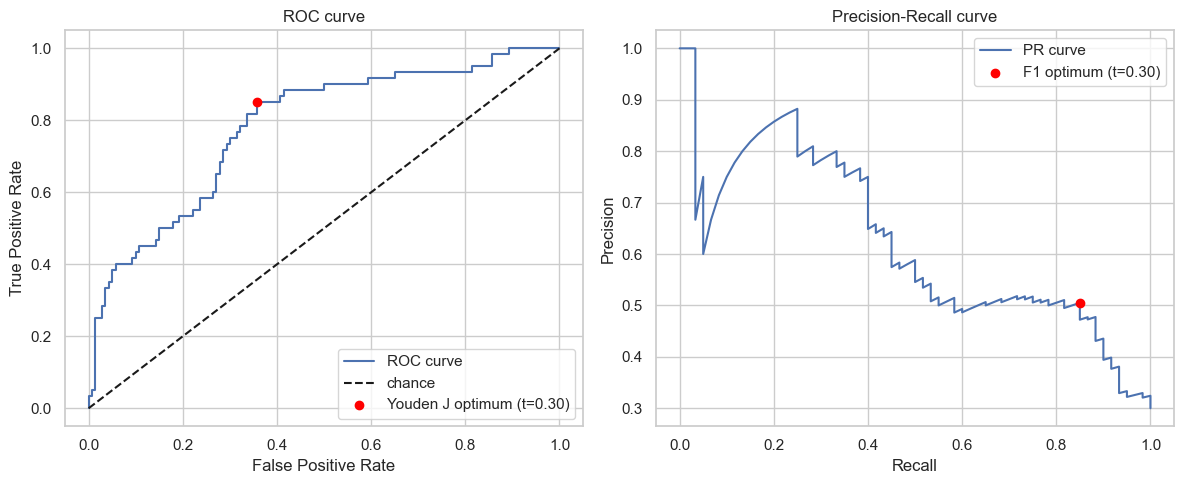

Youden's J optimal threshold: 0.301
F1-optimal threshold:         0.301


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.770,0.769231,0.333333,0.465116
Youden's J,0.300859,0.705,0.504950,0.850000,0.633540
F1-optimal,0.300859,0.705,0.504950,0.850000,0.633540


In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_rf.predict_proba(X_test)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- Random Forest reduces a single tree's variance by averaging many
  decorrelated trees (bagging + random feature subsets).
- `n_estimators` is a "the more the better, up to compute cost" knob, not a
  bias-variance one; `max_depth`/`min_samples_leaf`/`max_features` are the
  real regularization controls.
- The OOB score gives a nearly-free sanity check on generalization before
  even touching a held-out test set.
